<a href="https://colab.research.google.com/github/oooinr4018-web/-1/blob/main/%EC%9C%84%ED%97%98%EB%93%B1%EA%B8%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 3. 사고별 위험등급 예측

### 3.1 K-Means 클러스터링으로 위험등급 분류

'위험도_점수'를 활용하여 K-Means 클러스터링을 수행하고, Elbow Method를 통해 최적의 군집(K) 개수를 결정합니다. 이후 군집별 위험도 점수를 기반으로 '고위험', '중위험', '저위험' 등급을 부여합니다.

In [ ]:
# 1. 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib # 한글 깨짐 방지

In [ ]:
# 3. 'risk_score' 변수 추출 및 K-Means 입력용 데이터 변환 (2차원 배열 형태로)
X = risk_df[['위험도_점수']].values

### 3.2 Elbow Method를 활용한 최적의 K 찾기

WCSS(Within-Cluster Sum of Square) 값을 계산하여 K(군집 개수)에 따른 변화를 시각화합니다. WCSS가 급격히 줄어드는 지점이 최적의 K 값으로 고려될 수 있습니다.

'위험도_점수'에 NaN 값을 포함하여 972개의 행이 제거되었습니다.


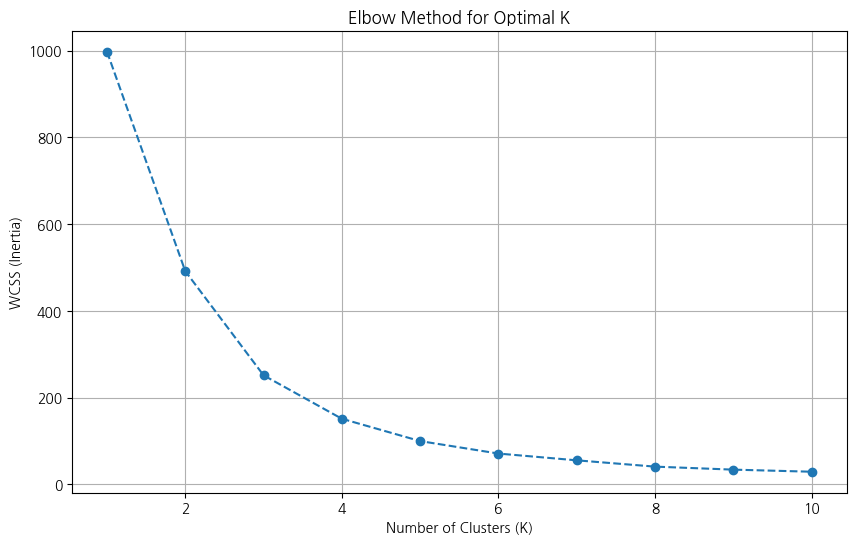

In [ ]:
# 4. Elbow Method(엘보우 방법)를 활용해 최적의 K(1부터 10까지)를 찾기 위한 WCSS(Inertia) 계산 및 시각화 코드

# KMeans 모델은 NaN 값을 허용하지 않으므로, '위험도_점수' 컬럼에 NaN이 있는 행은 제거합니다.
# 이 작업은 원본 'risk_df'에 영구적으로 반영되어 이후 K-Means 모델 학습 시에도 사용될 것입니다.
original_rows = len(risk_df)
risk_df.dropna(subset=['위험도_점수'], inplace=True)
dropped_rows = original_rows - len(risk_df)
if dropped_rows > 0:
    print(f"'위험도_점수'에 NaN 값을 포함하여 {dropped_rows}개의 행이 제거되었습니다.")

# 업데이트된 risk_df에서 K-Means 입력용 데이터 X를 다시 추출합니다.
X = risk_df[['위험도_점수']].values


wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init='auto') # n_init='auto' for KMeans
    kmeans.fit(X) # 이제 X는 NaN이 없는 깨끗한 데이터입니다.
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

### 3.3 K-Means 모델 학습 및 위험 등급 매핑

Elbow Method 결과를 바탕으로 최적의 K 값을 선택하여 K-Means 모델을 학습시키고, 각 군집의 평균 위험도 점수에 따라 '고위험', '중위험', '저위험' 등급을 부여합니다.

In [ ]:
# 5. 사용자가 시각화 확인 후 K 값을 지정하면(예: K=3), 해당 K 값으로 최종 K-Means 모델을 학습시키는 코드
# Elbow plot에서 K=3이 적절해 보이므로 K=3으로 설정합니다.
k = 3  # 사용자가 지정할 K 값

kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init='auto')
risk_df['cluster'] = kmeans.fit_predict(X)

# 6. 군집(Cluster) 번호별 'risk_score'의 평균을 계산하여,
#    평균 점수가 높은 순서대로 '고위험', '중위험', '저위험' (또는 1등급, 2등급, 3등급)으로 등급을 자동 매핑(Mapping)하는 코드
cluster_means = risk_df.groupby('cluster')['위험도_점수'].mean().sort_values(ascending=False)

# 등급 정의 (예: 1등급_초고위험, 2등급_심각위험, 3등급_고위험)
# 여기서는 간단히 K에 따라 등급을 나눕니다.
# 예시로 K=3일 경우 '고위험', '중위험', '저위험'으로 매핑
risk_labels = [f'{i+1}등급' for i in range(k)]
risk_grade_mapping = dict(zip(cluster_means.index, risk_labels))

# cluster_means가 정렬된 순서대로 라벨 매핑
sorted_clusters = cluster_means.index.tolist()
risk_grade_map = {}
# 예시로 3개 등급을 가정하여 '1등급_초고위험', '2등급_심각위험', '3등급_고위험' 부여
if k == 3:
    risk_grade_map[sorted_clusters[0]] = '1등급_초고위험'
    risk_grade_map[sorted_clusters[1]] = '2등급_심각위험'
    risk_grade_map[sorted_clusters[2]] = '3등급_고위험'
elif k == 4:
    risk_grade_map[sorted_clusters[0]] = '1등급_초고위험'
    risk_grade_map[sorted_clusters[1]] = '2등급_심각위험'
    risk_grade_map[sorted_clusters[2]] = '3등급_고위험'
    risk_grade_map[sorted_clusters[3]] = '4등급_저위험'
# 필요에 따라 다른 K 값에 대한 매핑 추가 가능

risk_df['위험등급'] = risk_df['cluster'].map(risk_grade_map)

# 7. 기존 데이터프레임 `risk_df`에 최종 등급이 부여된 `'위험등급'` 컬럼을 추가하고, 상위 5개 행을 확인하는 코드
display(risk_df.head())

,학교급,사고장소,사고형태,사고건수,평균보상액,평균학생수_천명,빈도율,log_빈도율,log_평균보상액,빈도_점수,심도_점수,위험도_점수,정밀_위험등급,매트릭스_타겟,cluster,위험등급
0,고등학교,가정,그밖의 손상 사고,1,"168,000","1,289",0,0,12,0,4,2,6등급_저위험,D군_모니터링 (저빈도+저심도),0,3등급_고위험
1,고등학교,가정,넘어짐,9,"622,667","1,289",0,0,13,0,5,3,4등급_중점관리,D군_모니터링 (저빈도+저심도),1,2등급_심각위험
2,고등학교,가정,움직이는 물체와의 부딪힘,1,"220,000","1,289",0,0,12,0,4,2,5등급_일반위험,D군_모니터링 (저빈도+저심도),0,3등급_고위험
3,고등학교,가정,이동 중 충격을 가함,1,"418,000","1,289",0,0,13,0,5,3,5등급_일반위험,D군_모니터링 (저빈도+저심도),1,2등급_심각위험
4,고등학교,강·바다·하천,1미터 미만의 높이에서 떨어짐,3,"797,333","1,289",0,0,14,0,5,3,4등급_중점관리,D군_모니터링 (저빈도+저심도),1,2등급_심각위험


### 3.4 머신러닝 분류 모델 구축 및 평가

K-Means 클러스터링으로 분류된 '위험등급'을 타겟 변수로 설정하고, '학교급', '사고장소', '사고형태'와 같은 학교 고유의 특성을 입력 변수로 활용하여 분류 모델을 구축합니다.

**데이터 누수 방지(Data Leakage Prevention)를 위해 `위험도_점수` 및 이를 구성하는 `사고건수`, `평균보상액`, `빈도_점수`, `심도_점수` 등은 입력 변수에서 제외합니다.**

In [ ]:
# 1. 필요한 라이브러리 임포트
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

import xgboost as xgb
import lightgbm as lgb

!pip install catboost
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib # 한글 깨짐 방지

# K-Means 클러스터링 결과가 담긴 risk_df를 사용합니다.
# 이미 한글 폰트 설정은 완료되어 있다고 가정합니다.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.5 MB/s eta 0:00:00


In [ ]:
# 2. 데이터 전처리 및 데이터셋 분할 (Train / Test = 8:2)

# 입력 변수(X)와 타겟 변수(Y) 정의
# '위험도_점수'와 'cluster' (위험등급 생성에 직접 사용된 컬럼), '정밀_위험등급' (다른 방식의 등급), '매트릭스_타겟'을 제외합니다.
# '사고건수', '평균보상액', '평균학생수_천명', '빈도율', 'log_빈도율', 'log_평균보상액', '빈도_점수', '심도_점수' 또한 위험도 점수 산출에 사용되었으므로 제외합니다.

features = ['학교급', '사고장소', '사고형태']
X = risk_df[features].copy()
Y = risk_df['위험등급'].copy()

# 타겟 변수('위험등급')를 모델 학습이 가능하도록 수치형으로 인코딩
# '1등급_초고위험': 2, '2등급_심각위험': 1, '3등급_고위험': 0 (더 높은 등급에 더 높은 숫자 부여)
y_mapping = {'1등급_초고위험': 2, '2등급_심각위험': 1, '3등급_고위험': 0}
Y_encoded = Y.map(y_mapping)

# 범주형 독립 변수에 라벨 인코딩 적용
for col in X.columns:
    if X[col].dtype == 'object':
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col])

# 데이터셋 분할 (Train / Test = 8:2)
X_train, X_test, y_train, y_test = train_test_split(X, Y_encoded, test_size=0.2, random_state=42, stratify=Y_encoded)

### 3. 모델 학습 및 평가

XGBoost, LightGBM, CatBoost 세 가지 분류 모델을 학습시키고, Test 데이터에 대한 Accuracy, Macro F1-Score, Confusion Matrix를 통해 성능을 비교합니다.


--- Training XGBoost Model ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:29:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost Model Evaluation ===
Accuracy: 0.6897
Macro F1-Score: 0.5652

Classification Report:
              precision    recall  f1-score   support

     3등급_고위험       0.68      0.67      0.67       170
    2등급_심각위험       0.71      0.74      0.72       219
    1등급_초고위험       0.40      0.24      0.30        17

    accuracy                           0.69       406
   macro avg       0.60      0.55      0.57       406
weighted avg       0.68      0.69      0.69       406


--- Training LightGBM Model ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 1622, number of used features: 3
[LightGBM] [Info] Start training from score -0.872268
[LightGBM] [Info] Start training from score -0.618335
[LightGBM] [Info] Start training from score -3.142920

=== LightGBM Model Evaluation ===
Accura

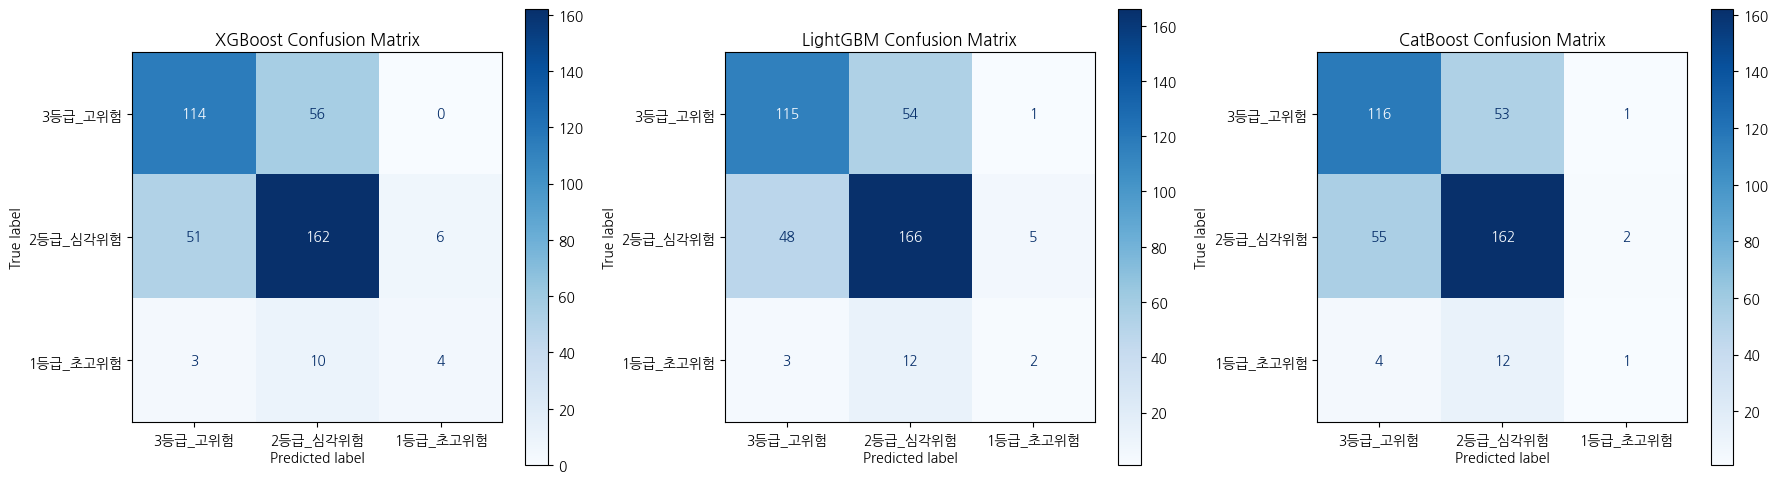

In [ ]:
results = {}

def evaluate_model(model, X_test, y_test, model_name, ax=None):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\n=== {model_name} Model Evaluation ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['3등급_고위험', '2등급_심각위험', '1등급_초고위험'])) # 등급 순서에 맞게 target_names 지정

    # Confusion Matrix 시각화
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['3등급_고위험', '2등급_심각위험', '1등급_초고위험'], cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'{model_name} Confusion Matrix')

    return accuracy, f1

# Confusion Matrix를 한 화면에 그리기 위한 설정
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # 1행 3열 서브플롯 생성

# XGBoost 분류기
print("\n--- Training XGBoost Model ---")
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
results['XGBoost'] = evaluate_model(xgb_model, X_test, y_test, 'XGBoost', ax=axes[0])

# LightGBM 분류기
print("\n--- Training LightGBM Model ---")
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train, y_train)
results['LightGBM'] = evaluate_model(lgb_model, X_test, y_test, 'LightGBM', ax=axes[1])

# CatBoost 분류기
print("\n--- Training CatBoost Model ---")
# CatBoost는 기본적으로 범주형 특성을 잘 처리하지만, 여기서는 Label Encoding된 데이터를 사용하므로 모든 특성을 수치형으로 간주합니다.
cat_model = CatBoostClassifier(random_state=42, verbose=0, iterations=100) # verbose=0으로 출력 억제
cat_model.fit(X_train, y_train)
results['CatBoost'] = evaluate_model(cat_model, X_test, y_test, 'CatBoost', ax=axes[2])

plt.tight_layout()
plt.show()

### 4. 모델 성능 시각화

세 가지 모델의 Macro F1-Score를 바 차트(Bar Chart)로 시각화하여 성능을 직관적으로 비교합니다.

/tmp/ipykernel_2323/1226198733.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=model_names, y=f1_scores, palette='viridis')


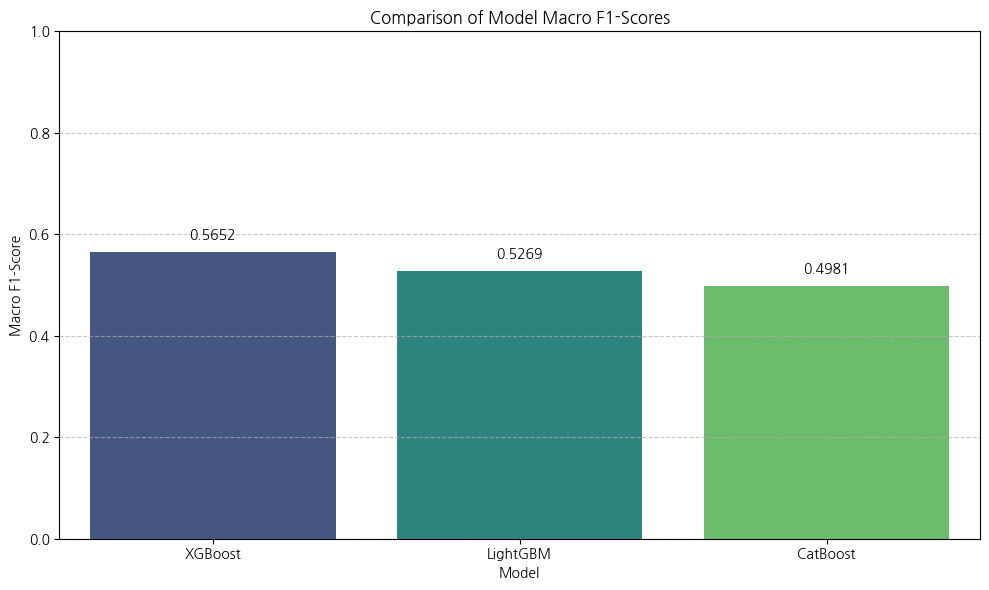

In [ ]:
# 모델별 F1-Score 추출
model_names = list(results.keys())
f1_scores = [score[1] for score in results.values()]

# F1-Score 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=model_names, y=f1_scores, palette='viridis')
plt.title('Comparison of Model Macro F1-Scores')
plt.xlabel('Model')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0) # F1-Score는 0에서 1 사이 값
for index, value in enumerate(f1_scores):
    plt.text(index, value + 0.02, f'{value:.4f}', ha='center', va='bottom')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Class Weight를 적용한 모델 학습 및 평가

클래스 불균형 문제를 완화하기 위해 `Class Weight`를 계산하여 각 모델에 적용한 후 다시 학습하고 평가합니다. 소수 클래스에 더 높은 가중치를 부여함으로써 모델이 해당 클래스의 샘플을 더 중요하게 학습하도록 유도합니다.

Calculated Class Weights:
{np.int64(0): np.float64(0.7974434611602753), np.int64(1): np.float64(0.6186117467581999), np.int64(2): np.float64(7.723809523809524)}

--- Training XGBoost Model (Weighted) ---

=== XGBoost (Weighted) Model Evaluation ===
Accuracy: 0.6823
Macro F1-Score: 0.5765

Classification Report:
              precision    recall  f1-score   support

     3등급_고위험       0.66      0.72      0.69       170
    2등급_심각위험       0.73      0.68      0.70       219
    1등급_초고위험       0.32      0.35      0.33        17

    accuracy                           0.68       406
   macro avg       0.57      0.58      0.58       406
weighted avg       0.69      0.68      0.68       406


--- Training LightGBM Model (Weighted) ---
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000090 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 79
[LightGBM] [Info] Number of data points in the train set: 1622, numb

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:44:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== LightGBM (Weighted) Model Evaluation ===
Accuracy: 0.6872
Macro F1-Score: 0.5909

Classification Report:
              precision    recall  f1-score   support

     3등급_고위험       0.67      0.72      0.70       170
    2등급_심각위험       0.74      0.68      0.71       219
    1등급_초고위험       0.33      0.41      0.37        17

    accuracy                           0.69       406
   macro avg       0.58      0.60      0.59       406
weighted avg       0.69      0.69      0.69       406


--- Training CatBoost Model (Weighted) ---

=== CatBoost (Weighted) Model Evaluation ===
Accuracy: 0.6330
Macro F1-Score: 0.5224

Classification Report:
              precision    recall  f1-score   support

     3등급_고위험       0.63      0.68      0.65       170
    2등급_심각위험       0.70      0.62      0.66       219
    1등급_초고위험       0.20      0.35      0.26        17

    accuracy                           0.63       406
   macro avg       0.51      0.55      0.52       406
weighted avg       0.65      

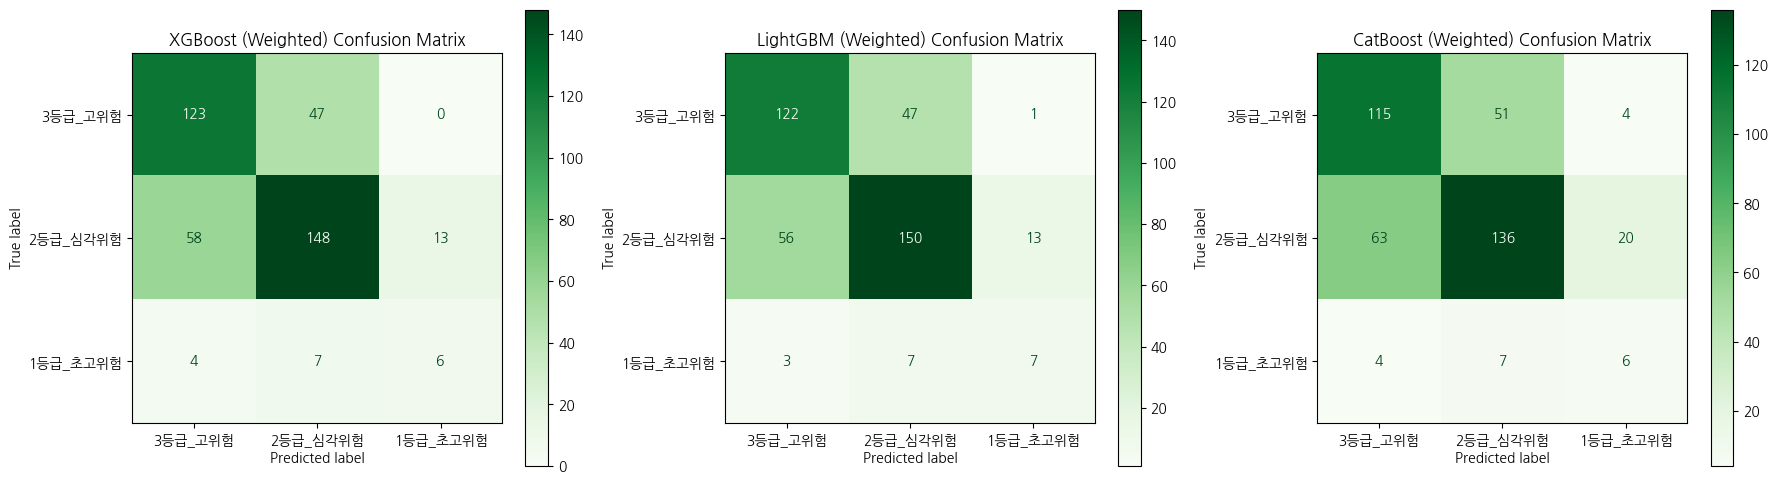

In [ ]:
from sklearn.utils import class_weight
import numpy as np

# 클래스 레이블과 y_train 데이터에서 클래스 가중치를 계산합니다.
# 'balanced' 모드는 클래스 빈도에 반비례하여 가중치를 자동으로 조정합니다.
classes = np.unique(y_train)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

# 계산된 클래스 가중치를 딕셔너리 형태로 변환합니다.
# {클래스 레이블: 가중치}
class_weights_dict = dict(zip(classes, class_weights))

print("Calculated Class Weights:")
print(class_weights_dict)

# 각 샘플에 해당하는 가중치 배열을 생성합니다.
# y_train의 각 요소에 해당하는 class_weights_dict의 값을 매핑합니다.
# 이 sample_weights는 XGBoost에 사용됩니다.
sample_weights = np.array([class_weights_dict[label] for label in y_train])

weighted_results = {}

def evaluate_weighted_model(model, X_test, y_test, model_name, ax=None):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\n=== {model_name} (Weighted) Model Evaluation ===")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Macro F1-Score: {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['3등급_고위험', '2등급_심각위험', '1등급_초고위험']))

    # Confusion Matrix 시각화
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['3등급_고위험', '2등급_심각위험', '1등급_초고위험'], cmap=plt.cm.Greens, ax=ax)
    ax.set_title(f'{model_name} (Weighted) Confusion Matrix')

    return accuracy, f1


# Confusion Matrix를 한 화면에 그리기 위한 설정 (Weighted Models)
fig_w, axes_w = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost 분류기 (Weighted)
print("\n--- Training XGBoost Model (Weighted) ---")
xgb_model_w = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model_w.fit(X_train, y_train, sample_weight=sample_weights)
weighted_results['XGBoost_Weighted'] = evaluate_weighted_model(xgb_model_w, X_test, y_test, 'XGBoost', ax=axes_w[0])

# LightGBM 분류기 (Weighted)
print("\n--- Training LightGBM Model (Weighted) ---")
lgb_model_w = lgb.LGBMClassifier(random_state=42, class_weight=class_weights_dict)
lgb_model_w.fit(X_train, y_train)
weighted_results['LightGBM_Weighted'] = evaluate_weighted_model(lgb_model_w, X_test, y_test, 'LightGBM', ax=axes_w[1])

# CatBoost 분류기 (Weighted)
print("\n--- Training CatBoost Model (Weighted) ---")
cat_model_w = CatBoostClassifier(random_state=42, verbose=0, iterations=100, class_weights=list(class_weights_dict.values()))
cat_model_w.fit(X_train, y_train)
weighted_results['CatBoost_Weighted'] = evaluate_weighted_model(cat_model_w, X_test, y_test, 'CatBoost', ax=axes_w[2])

plt.tight_layout()
plt.show()

### 원본 모델과 Class Weight 적용 모델의 Macro F1-Score 비교


--- Macro F1-Score Comparison ---


,XGBoost,LightGBM,CatBoost
Original,1,1,0
Weighted,1,1,1


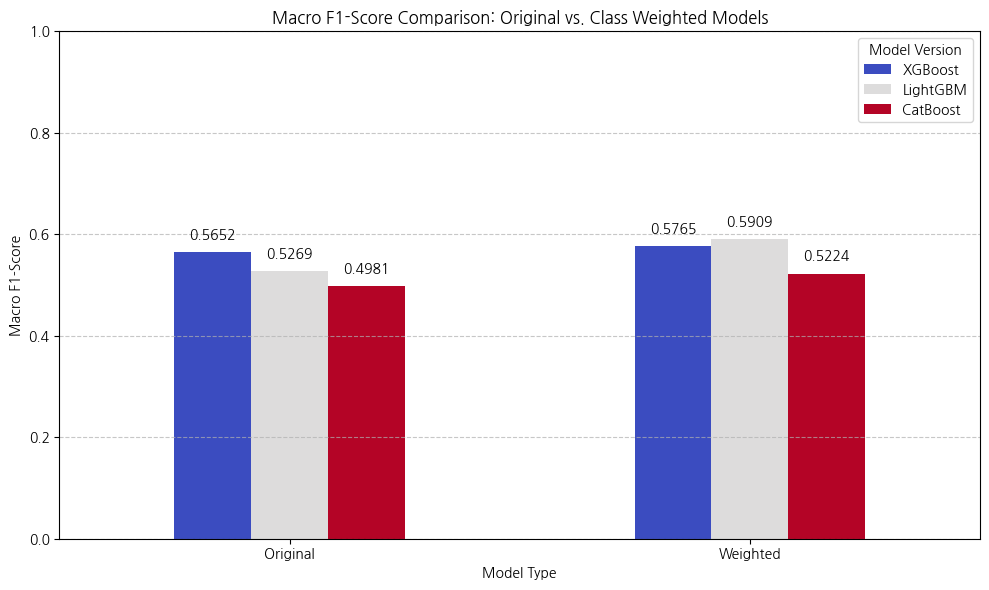

In [ ]:
# 원본 모델의 F1-Score 추출
original_f1_scores = {name: score[1] for name, score in results.items()}

# 가중치 적용 모델의 F1-Score 추출
weighted_f1_scores = {name.replace('_Weighted', ''): score[1] for name, score in weighted_results.items()}

# 데이터프레임으로 변환하여 비교 용이하게
comparison_df = pd.DataFrame({
    'Original': original_f1_scores,
    'Weighted': weighted_f1_scores
}).T # Transpose for easier plotting

print("\n--- Macro F1-Score Comparison ---")
display(comparison_df)

# 시각화
fig, ax = plt.subplots(figsize=(10, 6))
comparison_df.plot(kind='bar', ax=ax, rot=0, cmap='coolwarm')
plt.title('Macro F1-Score Comparison: Original vs. Class Weighted Models')
plt.xlabel('Model Type')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
plt.legend(title='Model Version')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 각 막대 위에 값 표시
for container in ax.containers:
    for i, v in enumerate(container.patches):
        ax.text(v.get_x() + v.get_width() / 2, v.get_height() + 0.02,
                f'{v.get_height():.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

### LightGBM 하이퍼파라미터 튜닝 (Optuna 사용)

Optuna 라이브러리를 사용하여 LightGBM 모델의 하이퍼파라미터를 최적화합니다. Macro F1-Score를 최대화하는 방향으로 튜닝을 진행할 것입니다.

[I 2026-07-13 07:59:14,692] A new study created in memory with name: no-name-a9e90e0b-95dd-4290-8bd1-b8f8ebbeee80



--- Starting Optuna Hyperparameter Tuning for LightGBM ---


  0%|          | 0/50 [00:00<?, ?it/s]

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best 

AttributeError: 'NoneType' object has no attribute 'set_title'

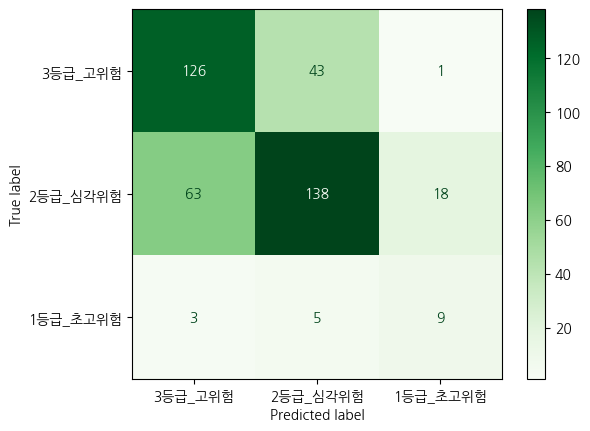

In [ ]:
!pip install optuna

# 필요한 라이브러리 임포트
import optuna
from sklearn.model_selection import StratifiedKFold

# Optuna Objective 함수 정의
def objective(trial):
    # LightGBM 하이퍼파라미터 제안
    params = {
        'objective': 'multiclass',
        'num_class': len(np.unique(y_train)),
        'metric': 'multi_logloss',
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': 42,
        'n_jobs': -1,
        'class_weight': class_weights_dict, # 클래스 가중치 적용
    }

    # 교차 검증을 위한 StratifiedKFold 설정
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        model = lgb.LGBMClassifier(**params)
        model.fit(X_train_fold, y_train_fold)
        y_pred_val = model.predict(X_val_fold)
        f1 = f1_score(y_val_fold, y_pred_val, average='macro')
        f1_scores.append(f1)

    return np.mean(f1_scores)

# Optuna Study 생성 및 최적화
print("\n--- Starting Optuna Hyperparameter Tuning for LightGBM ---")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n--- Optuna Tuning Results ---")
print(f"Best trial: {study.best_trial.value:.4f}")
print("Best parameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# 최적의 하이퍼파라미터로 LightGBM 모델 재학습
best_lgbm_params = study.best_trial.params
best_lgbm_params['class_weight'] = class_weights_dict # 클래스 가중치 재적용

print("\n--- Training LightGBM Model with Best Hyperparameters (Weighted) ---")
tuned_lgbm_model = lgb.LGBMClassifier(**best_lgbm_params, random_state=42, n_jobs=-1)
tuned_lgbm_model.fit(X_train, y_train)

# 튜닝된 모델 평가
weighted_results['LightGBM_Tuned'] = evaluate_weighted_model(tuned_lgbm_model, X_test, y_test, 'LightGBM_Tuned')

# F1-Score 비교 업데이트
original_f1_scores['LightGBM'] = results['LightGBM'][1] # 원본 LightGBM F1-Score
weighted_f1_scores['LightGBM'] = weighted_results['LightGBM_Weighted'][1] # 가중치 적용 LightGBM F1-Score
weighted_f1_scores['LightGBM_Tuned'] = weighted_results['LightGBM_Tuned'][1] # 튜닝된 LightGBM F1-Score

# 데이터프레임으로 변환하여 비교 용이하게
comparison_df_tuned = pd.DataFrame({
    'Original': original_f1_scores,
    'Weighted': weighted_f1_scores
}).T

print("\n--- Macro F1-Score Comparison (with Tuned LightGBM) ---")
display(comparison_df_tuned)

# 시각화
fig, ax = plt.subplots(figsize=(12, 7))
comparison_df_tuned.plot(kind='bar', ax=ax, rot=0, cmap='coolwarm')
plt.title('Macro F1-Score Comparison: Original vs. Class Weighted vs. Tuned Models')
plt.xlabel('Model Type')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
plt.legend(title='Model Version')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 각 막대 위에 값 표시
for container in ax.containers:
    for i, v in enumerate(container.patches):
        ax.text(v.get_x() + v.get_width() / 2, v.get_height() + 0.02,
                f'{v.get_height():.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

LightGBM 하이퍼파라미터 튜닝하여 F1-Score 최대화
- Original: 0.5269
- Weighted: 0.5909
- Tuned: 0.5967

하이퍼파라미터 튜닝을 통해 LightGBM 모델의 성능이 더욱 향상되었음을 확인할 수 있음.
